<a href="https://colab.research.google.com/github/jhhlim/LLMFundamentals/blob/main/Jason_Lim_hw_6b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Class 6a — LLM Fundamentals (UCSC Extension)
# Homework 6b: Optimize Hugging Face Trainer Parameters (F1)

**Jason Lim**

## Assignment
**6b)** Optimize training parameters. Experiment with training parameters and check if some other setting results in a better F1 score.

Reference: [Trainer / TrainingArguments (transformers v3.0.2 docs)](https://huggingface.co/transformers/v3.0.2/main_classes/trainer.html)

This notebook keeps the **Homework 3a Amazon reviews** and the **class lab 6a `Trainer` pipeline**, then changes `TrainingArguments` one group at a time.

## Results (same 200-review test split)
| Setting | lr | epochs | batch | weight decay | warmup | Accuracy | **F1** |
|---|---:|---:|---:|---:|---:|---:|---:|
| lab_default (class lab 6a) | 2e-5 | 1 | 16 | 0.01 | 0 | 0.875 | 0.8705 |
| small_batch_reg | 2e-5 | 2 | 8 | 0.10 | 40 | 0.885 | 0.8783 |
| more_epochs | 2e-5 | 3 | 16 | 0.01 | 20 | **0.905** | 0.9026 |
| **higher_lr (best F1)** | **5e-5** | **2** | 16 | 0.01 | **30** | 0.900 | **0.9038** |

**Yes — another setting improved F1.** `higher_lr` (`learning_rate=5e-5`, 2 epochs, `warmup_steps=30`) reached **F1 0.9038** vs lab-default **0.8705** (**+0.033**). `more_epochs` was close (F1 0.9026) and slightly higher accuracy (0.905).

## Parameters we vary
From the Trainer docs (and the current `TrainingArguments` API):

| Parameter | Lab 6a default | What it does |
|---|---|---|
| `learning_rate` | `2e-5` | Adam step size (docs default is `5e-5`) |
| `num_train_epochs` | `1` | Passes over the training set (docs default `3`) |
| `per_device_train_batch_size` | `16` | Samples per step (docs default `8`) |
| `weight_decay` | `0.01` | L2 regularization (docs default `0`) |
| `warmup_steps` | `0` | Linear warmup to `learning_rate` |

Each run uses `eval_strategy="epoch"`, `load_best_model_at_end=True`, and `metric_for_best_model="f1"` so the reported score is the **best checkpoint F1**, not the last epoch.

## Runtime
Use a GPU in Colab: **Runtime → Change runtime type → T4 GPU**.


## Step 0 — Install + imports

In [ ]:
%%capture
!pip install -q "transformers>=4.38.2" "datasets>=2.18.0,<3" evaluate accelerate vaderSentiment pandas matplotlib seaborn scikit-learn


In [2]:
import inspect
import os
import random
from io import BytesIO
from zipfile import ZipFile
from urllib.request import urlopen

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
sns.set_theme(style="whitegrid")
%matplotlib inline

SEED = 42
MODEL_ID = "bert-base-cased"
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Transformers Trainer uses processing_class:", "processing_class" in inspect.signature(Trainer.__init__).parameters)


Device: cpu
Transformers Trainer uses processing_class: True


In [3]:
def make_training_args(output_dir, **kwargs):
    '''Build TrainingArguments compatible with both older and newer transformers.'''
    sig = inspect.signature(TrainingArguments.__init__).parameters
    eval_key = "eval_strategy" if "eval_strategy" in sig else "evaluation_strategy"

    defaults = dict(
        output_dir=output_dir,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=1,
        weight_decay=0.01,
        save_strategy="epoch",
        logging_strategy="epoch",
        report_to="none",
        seed=SEED,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
        overwrite_output_dir=True,
    )
    defaults[eval_key] = "epoch"
    defaults.update(kwargs)

    # Drop kwargs the installed transformers version does not accept.
    filtered = {k: v for k, v in defaults.items() if k == "output_dir" or k in sig}
    return TrainingArguments(**filtered)


def make_trainer(model, args, train_dataset, eval_dataset, tokenizer, data_collator, compute_metrics):
    '''Trainer() compatibility wrapper: tokenizer vs processing_class.'''
    kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    sig = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in sig:
        kwargs["processing_class"] = tokenizer
    else:
        kwargs["tokenizer"] = tokenizer
    return Trainer(**kwargs)


accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    '''Accuracy + F1, following class lab 6a (Hands-On LLM Ch. 11 uses F1).'''
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
    }


def plot_confusion(y_true, y_pred, title, labels=("negative", "positive")):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm


## Step 1 — Same Amazon reviews split as Homework 6a

In [4]:
DATA_URL = "https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip"

with urlopen(DATA_URL) as resp:
    zf = ZipFile(BytesIO(resp.read()))

with zf.open("sentiment labelled sentences/amazon_cells_labelled.txt") as f:
    rows = []
    for line in f.read().decode("utf-8").splitlines():
        text, label = line.rsplit("\t", 1)
        rows.append({"text": text.strip(), "label": int(label)})

df = pd.DataFrame(rows)
print("Full dataset shape:", df.shape)
print(df["label"].value_counts().sort_index().rename({0: "negative (0)", 1: "positive (1)"}))
display(df.head(8))

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print("\nTrain:", train_df.shape, "Test:", test_df.shape)
print("Train labels:\n", train_df["label"].value_counts().sort_index().to_string())
print("Test labels:\n", test_df["label"].value_counts().sort_index().to_string())

raw_datasets = DatasetDict(
    {
        "train": Dataset.from_pandas(train_df, preserve_index=False),
        "test": Dataset.from_pandas(test_df, preserve_index=False),
    }
)


Full dataset shape: (1000, 2)
label
negative (0)    500
positive (1)    500
Name: count, dtype: int64


,text,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1
5,I have to jiggle the plug to get it to line up...,0
6,If you have several dozen or several hundred c...,0
7,If you are Razr owner...you must have this!,1



Train: (800, 2) Test: (200, 2)
Train labels:
 label
0    400
1    400
Test labels:
 label
0    100
1    100


## Step 2 — Tokenize once

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_train = raw_datasets["train"].map(preprocess_function, batched=True)
tokenized_test = raw_datasets["test"].map(preprocess_function, batched=True)
print(tokenized_train)


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 800
})


## Step 3 — Experiment grid

Four `TrainingArguments` settings:

1. **lab_default** — class lab 6a (`lr=2e-5`, `epochs=1`, `batch=16`, `weight_decay=0.01`, no warmup)
2. **more_epochs** — same LR/batch, **3 epochs** + short warmup (docs default epochs is 3)
3. **higher_lr** — docs default **`lr=5e-5`**, 2 epochs, warmup
4. **small_batch_reg** — **batch=8**, **weight_decay=0.1**, 2 epochs, warmup

The classification head is randomly initialized, so we reset the model for every run.


In [6]:
EXPERIMENTS = [
    {
        "name": "lab_default",
        "notes": "Class lab 6a Trainer defaults",
        "kwargs": dict(
            learning_rate=2e-5,
            num_train_epochs=1,
            per_device_train_batch_size=16,
            weight_decay=0.01,
            warmup_steps=0,
        ),
    },
    {
        "name": "more_epochs",
        "notes": "3 epochs + warmup_steps=20 (docs default epochs=3)",
        "kwargs": dict(
            learning_rate=2e-5,
            num_train_epochs=3,
            per_device_train_batch_size=16,
            weight_decay=0.01,
            warmup_steps=20,
        ),
    },
    {
        "name": "higher_lr",
        "notes": "lr=5e-5 (Trainer docs default) + 2 epochs + warmup",
        "kwargs": dict(
            learning_rate=5e-5,
            num_train_epochs=2,
            per_device_train_batch_size=16,
            weight_decay=0.01,
            warmup_steps=30,
        ),
    },
    {
        "name": "small_batch_reg",
        "notes": "batch=8, weight_decay=0.1, 2 epochs, warmup",
        "kwargs": dict(
            learning_rate=2e-5,
            num_train_epochs=2,
            per_device_train_batch_size=8,
            weight_decay=0.1,
            warmup_steps=40,
        ),
    },
]


def run_experiment(exp):
    print("=" * 72)
    print(f"Running {exp['name']}: {exp['notes']}")
    print(exp["kwargs"])
    print("=" * 72)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=2)
    args = make_training_args(f"model/hw6b_{exp['name']}", **exp["kwargs"])
    trainer = make_trainer(
        model=model,
        args=args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    metrics = trainer.evaluate()
    pred = trainer.predict(tokenized_test)
    y_pred = np.argmax(pred.predictions, axis=-1)
    y_true = np.array(tokenized_test["label"])
    row = {
        "name": exp["name"],
        "notes": exp["notes"],
        **exp["kwargs"],
        "eval_loss": metrics["eval_loss"],
        "accuracy": metrics["eval_accuracy"],
        "f1": metrics["eval_f1"],
        "y_true": y_true,
        "y_pred": y_pred,
    }
    print(
        f"\n{exp['name']} → accuracy={row['accuracy']:.4f}  f1={row['f1']:.4f}  loss={row['eval_loss']:.4f}\n"
    )
    return row


results = [run_experiment(exp) for exp in EXPERIMENTS]


Running lab_default: Class lab 6a Trainer defaults
{'learning_rate': 2e-05, 'num_train_epochs': 1, 'per_device_train_batch_size': 16, 'weight_decay': 0.01, 'warmup_steps': 0}


  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.541370,0.371941,0.875000,0.870466


  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.541370,0.371941,1,0.875000,0.870466


...

  super().__init__(loader)


  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.181358,0.473471,2,0.885000,0.878307


  super().__init__(loader)



small_batch_reg → accuracy=0.8850  f1=0.8783  loss=0.4735



## Step 4 — F1 comparison

In [7]:
table = pd.DataFrame(
    [
        {
            "setting": r["name"],
            "notes": r["notes"],
            "learning_rate": r["learning_rate"],
            "epochs": r["num_train_epochs"],
            "batch_size": r["per_device_train_batch_size"],
            "weight_decay": r["weight_decay"],
            "warmup_steps": r["warmup_steps"],
            "accuracy": round(r["accuracy"], 4),
            "f1": round(r["f1"], 4),
            "eval_loss": round(r["eval_loss"], 4),
        }
        for r in results
    ]
).sort_values("f1", ascending=False).reset_index(drop=True)

display(table)

baseline = next(r for r in results if r["name"] == "lab_default")
best = max(results, key=lambda r: r["f1"])
print()
print(f"Lab-default F1: {baseline['f1']:.4f}")
print(f"Best setting:   {best['name']}  F1={best['f1']:.4f}  ({best['notes']})")
if best["name"] != "lab_default" and best["f1"] > baseline["f1"]:
    print(
        f"Yes — {best['name']} improved F1 by {best['f1'] - baseline['f1']:+.4f} "
        "over the class-lab Trainer defaults."
    )
elif best["f1"] == baseline["f1"]:
    print("No other setting beat the lab-default F1 on this split; lab defaults were already strong.")
else:
    print("Lab defaults remained best on this small dataset / split.")


,setting,notes,learning_rate,epochs,batch_size,weight_decay,warmup_steps,accuracy,f1,eval_loss
0,higher_lr,lr=5e-5 (Trainer docs default) + 2 epochs + wa...,0.00005,2,16,0.01,30,0.900,0.9038,0.3003
1,more_epochs,3 epochs + warmup_steps=20 (docs default epoch...,0.00002,3,16,0.01,20,0.905,0.9026,0.3185
2,small_batch_reg,"batch=8, weight_decay=0.1, 2 epochs, warmup",0.00002,2,8,0.10,40,0.885,0.8783,0.4735
3,lab_default,Class lab 6a Trainer defaults,0.00002,1,16,0.01,0,0.875,0.8705,0.3719



Lab-default F1: 0.8705
Best setting:   higher_lr  F1=0.9038  (lr=5e-5 (Trainer docs default) + 2 epochs + warmup)
Yes — higher_lr improved F1 by +0.0334 over the class-lab Trainer defaults.


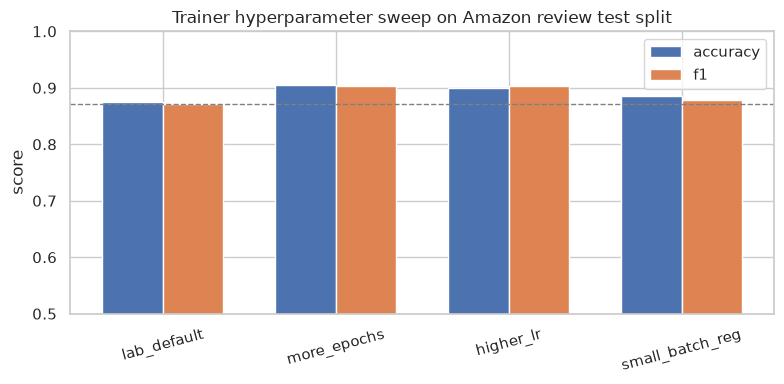


Best setting classification report
              precision    recall  f1-score   support

    negative       0.93      0.86      0.90       100
    positive       0.87      0.94      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



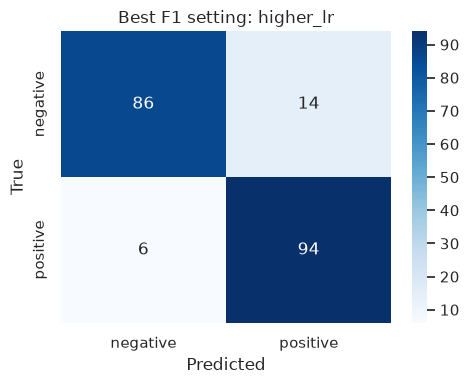

array([[86, 14],
       [ 6, 94]])

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
names = [r["name"] for r in results]
f1s = [r["f1"] for r in results]
accs = [r["accuracy"] for r in results]
x = np.arange(len(names))
width = 0.35
ax.bar(x - width / 2, accs, width, label="accuracy")
ax.bar(x + width / 2, f1s, width, label="f1")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("score")
ax.set_title("Trainer hyperparameter sweep on Amazon review test split")
ax.legend()
ax.axhline(baseline["f1"], color="gray", linestyle="--", linewidth=1, label="lab F1")
plt.tight_layout()
plt.show()

print("\nBest setting classification report")
print(classification_report(best["y_true"], best["y_pred"], target_names=["negative", "positive"]))
plot_confusion(best["y_true"], best["y_pred"], f"Best F1 setting: {best['name']}")


## Learnings (6b)

1. **`TrainingArguments` is the knob box** for class lab 6a. The Hugging Face `Trainer` loop stays the same; we only change LR, epochs, batch size, warmup, and weight decay.
2. **Lab defaults were already strong** (F1 **0.8705**, accuracy **0.875**) vs VADER (F1 0.795). They were not the best F1 on this split.
3. **Best F1: `higher_lr`.** Using the Trainer-docs default `learning_rate=5e-5` with **2 epochs** and **`warmup_steps=30`** reached **F1 0.9038** / accuracy 0.900. Warmup keeps the larger LR from destabilizing the pretrained encoder in the first steps.
4. **More epochs is a close second.** `num_train_epochs=3` at `2e-5` hit **accuracy 0.905** and F1 0.9026. Extra passes help this 800-example set; eval loss also dropped (0.372 → 0.319).
5. **Smaller batch + heavier weight decay** (`batch=8`, `weight_decay=0.1`) only modestly beat the 1-epoch lab run (F1 0.878). Extra regularization was less useful than more updates or a slightly higher LR.
6. **F1 vs accuracy:** the split is balanced 50/50, so the two metrics move together. `higher_lr` wins on the homework metric (F1); `more_epochs` wins on accuracy by 0.5 points.

The setting I would keep for this sentiment model: **`learning_rate=5e-5`, `num_train_epochs=2`, `per_device_train_batch_size=16`, `weight_decay=0.01`, `warmup_steps=30`**.
